In [1]:
import pandas as pd #loading data set
import numpy as np # mathematical calculation
import re # Regular Expression used for cleaning the data
import nltk # for basics
import matplotlib.pyplot as plt # visualization
from nltk.corpus import stopwords # to remove be verbs unwanted words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [2]:
# library for punctuation for sentiemnet
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
data={
  "Review":[
    "The food was delicious and the delivery was very quick.",
    "The order arrived late and the food was cold.",
    "Excellent customer service and tasty meals.",
    "The packaging was damaged and food spilled everywhere.",
    "Amazing taste and good portion size.",
    "Poor quality food and terrible dining experience.",
    "Fast delivery and neat packaging.",
    "The burger was undercooked and not fresh.",
    "Great service and friendly staff.",
    "Late delivery and rude customer support.",
    "The pizza was hot and very flavorful.",
    "The order was missing several items.",
    "Fresh ingredients and excellent presentation.",
    "The food was too salty and difficult to eat.",
    "Reasonable prices and good quality meals.",
    "Customer support did not respond to my complaint.",
    "Loved the dessert, it was amazing.",
    "The food arrived cold and soggy.",
    "Quick service and clean packaging.",
    "Very disappointing experience and poor food quality.",
    "The restaurant maintained excellent hygiene standards.",
    "Delivery took more than an hour.",
    "The pasta was perfectly cooked and delicious.",
    "The meal was overpriced for its quality.",
    "Staff were polite and attentive.",
    "Packaging leaked and created a mess.",
    "Best restaurant experience I have had recently.",
    "The chicken was dry and overcooked.",
    "Fast service and fresh food.",
    "The order tracking information was inaccurate.",
    "Excellent taste and affordable prices.",
    "Customer service solved my issue quickly.",
    "The food lacked flavor and seasoning.",
    "Delivery was faster than expected.",
    "Received the wrong order from the restaurant.",
    "Wonderful ambiance and quality food.",
    "The soup was cold when it arrived.",
    "Highly recommend this restaurant to everyone.",
    "Very long waiting time for the order.",
    "Fresh food and attractive packaging.",
    "The restaurant ignored my special instructions.",
    "Outstanding service and delicious meals.",
    "Food portions were too small for the price.",
    "Friendly delivery person and quick service.",
    "The meal tasted stale and unpleasant.",
    "Great value for money and excellent quality.",
    "Poor customer support and delayed response.",
    "The food was fresh, hot, and flavorful.",
    "Terrible experience, I will not order again.",
    "Excellent food quality and prompt delivery."
]

}
df = pd.DataFrame(data)

In [4]:
print("Restaurant Reviews Dataset")
print(df.head())

Customer Reviews Dataset
                                     Customer_Review
0  The food was delicious and the delivery was ve...
1      The order arrived late and the food was cold.
2        Excellent customer service and tasty meals.
3  The packaging was damaged and food spilled eve...
4               Amazing taste and good portion size.


In [5]:
stop_words = set(stopwords.words('english'))

def clean_text(text):

  text=text.lower()
  print('lower case',text)
  # remove special charater and number
  text = re.sub(r'[^a-zA-Z\s]','',text)
  print('special character',text)
  #Tokenization
  words = word_tokenize(text)
  print('tokenization')
  # reomve stopwords
  words = [word for word in words if word not in stop_words]
  print('stopwords',words)
  # join words again
  cleaned_text =" ".join(words)

  return cleaned_text

In [9]:


# apply cleaning function
df['cleaned review'] = df['Customer_Review'].apply(clean_text)
print("\nCleaned Review")
print(df[['Customer_Review','cleaned review']])

lower case the food was delicious and the delivery was very quick.
special character the food was delicious and the delivery was very quick
tokenization
stopwords ['food', 'delicious', 'delivery', 'quick']
lower case the order arrived late and the food was cold.
special character the order arrived late and the food was cold
tokenization
stopwords ['order', 'arrived', 'late', 'food', 'cold']
lower case excellent customer service and tasty meals.
special character excellent customer service and tasty meals
tokenization
stopwords ['excellent', 'customer', 'service', 'tasty', 'meals']
lower case the packaging was damaged and food spilled everywhere.
special character the packaging was damaged and food spilled everywhere
tokenization
stopwords ['packaging', 'damaged', 'food', 'spilled', 'everywhere']
lower case amazing taste and good portion size.
special character amazing taste and good portion size
tokenization
stopwords ['amazing', 'taste', 'good', 'portion', 'size']
lower case poor qual

In [13]:
print(clean_text(df['Customer_Review'].iloc[0]))

lower case the food was delicious and the delivery was very quick.
special character the food was delicious and the delivery was very quick
tokenization
stopwords ['food', 'delicious', 'delivery', 'quick']
food delicious delivery quick


In [16]:
# sentiment analysis

sia = SentimentIntensityAnalyzer()
def analyzer_sentiment(review):
  score = sia.polarity_scores(review)
  compound = score['compound']
  if compound >= 0.05:
    return "positive"

  elif compound <= -0.05:
    return "negative"
  else:
    return "neutral"

#apply sentiment analysis
df['Sentiment'] = df['cleaned review'].apply(analyzer_sentiment)
print("\nSentiment Analysis")
print(df[['Customer_Review','Sentiment']])


Sentiment Analysis
                                      Customer_Review Sentiment
0   The food was delicious and the delivery was ve...  positive
1       The order arrived late and the food was cold.   neutral
2         Excellent customer service and tasty meals.  positive
3   The packaging was damaged and food spilled eve...  negative
4                Amazing taste and good portion size.  positive
5   Poor quality food and terrible dining experience.  negative
6                   Fast delivery and neat packaging.  positive
7           The burger was undercooked and not fresh.  positive
8                   Great service and friendly staff.  positive
9            Late delivery and rude customer support.  negative
10              The pizza was hot and very flavorful.   neutral
11               The order was missing several items.  negative
12      Fresh ingredients and excellent presentation.  positive
13       The food was too salty and difficult to eat.  negative
14          Reasonab

In [17]:
all_words=" ".join(df['cleaned review'])
word_list = all_words.split()

#count word frequency

word_freq= Counter(word_list)

#display top 10 keywords
print("\nTop  10 Common Keywords")
print(word_freq.most_common(10))



Top  10 Common Keywords
[('food', 14), ('delivery', 7), ('service', 7), ('quality', 7), ('order', 6), ('excellent', 6), ('customer', 5), ('packaging', 5), ('fresh', 5), ('restaurant', 5)]


In [18]:
# identify common complaints
negative_reviews = df[df['Sentiment'] == 'negative'] # Corrected: 'Negative' to 'negative'
negative_words_combined = " ".join(negative_reviews['cleaned review']) # Combine all cleaned negative reviews
negative_word_list = negative_words_combined.split() # Split the combined string into a list of words

# Count word frequency
word_freq_negative = Counter(negative_word_list) # Corrected: 'counter' to 'Counter'

print("\n top 10 negative keywords")
print(word_freq_negative.most_common(10))


 top 10 negative keywords
[('food', 4), ('poor', 3), ('experience', 3), ('order', 3), ('packaging', 2), ('quality', 2), ('terrible', 2), ('customer', 2), ('support', 2), ('damaged', 1)]


In [19]:
sentiment_counts = df['Sentiment'].value_counts()
sentiment_counts

,count
Sentiment,
positive,26
neutral,13
negative,11


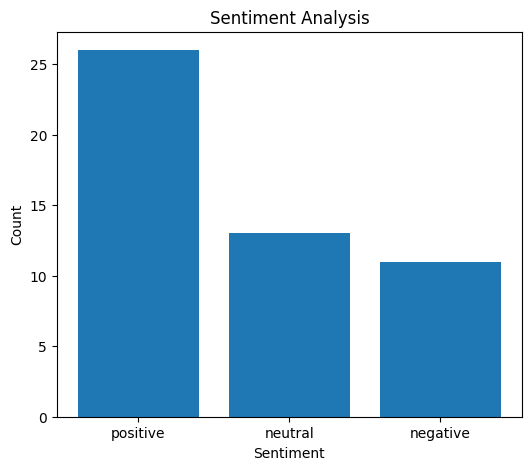

In [20]:
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(6,5))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Analysis")
plt.show()

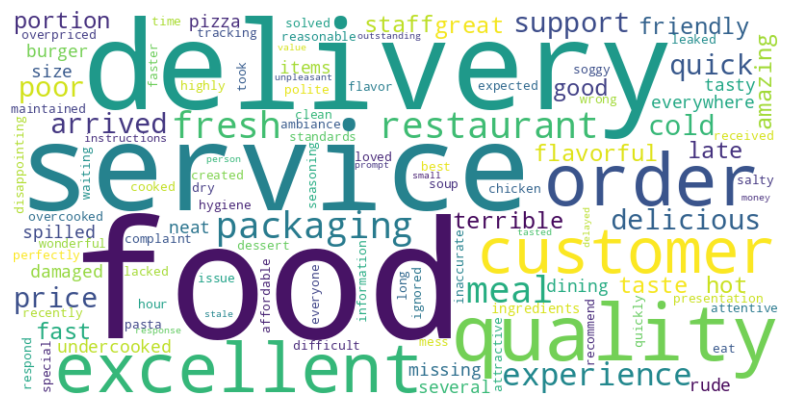

In [21]:
wordcloud = WordCloud(
    width = 800,
    height = 400,
    background_color ='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()